In [1]:
import pandas as pd

df = pd.read_csv(
    "proteinGroups_search-pilot_PancreaticIslets.txt",
    sep="\t",
    low_memory=False
)

df.head()


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Peptides Islet1,Peptides Islet2,...,Potential contaminant,id,Peptide IDs,Peptide is razor,Mod. peptide IDs,Evidence IDs,MS/MS IDs,Best MS/MS,Oxidation (M) site IDs,Oxidation (M) site positions
0,Q9H1X3-3;A0A024R161;P50151,Q9H1X3-3;A0A024R161;P50151,1;1;1,1;1;1,1;1;1,Guanine nucleotide-binding protein subunit gam...,hCG_1994888;GNG10,;;,0.0,0.0,...,NaN,0.0,5278,TRUE,5699,28719,22253,22253,NaN,NaN
1,A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,1;1,1;1,1;1,Translation machinery-associated protein 7,hCG_2014768;TMA7,;,0.0,0.0,...,NaN,1.0,16797,TRUE,18083,92127;92128;92129;92130;92131;92132;92133;9213...,71474;71475;71476;71477;71478,71475,NaN,NaN
2,A0A024R216;Q9Y3E1;H3BPQ6;H3BPM9,A0A024R216;Q9Y3E1,6;6;2;2,4;4;1;2,4;4;1;2,Hepatoma-derived growth factor-related protein 3,HDGFRP3,;,1.0,0.0,...,NaN,2.0,1446;15361;17962;19919;32503;49365,True;True;False;True;True;False,1556;16549;19339;21441;35506;53689,7437;7438;7439;7440;83998;83999;84000;84001;84...,5628;5629;5630;5631;5632;65355;65356;65357;653...,5629;65362;76402;89015;149381;222276,NaN,NaN
3,A0A024R341;Q6I9Y2;F8WF22,A0A024R341;Q6I9Y2;F8WF22,3;3;2,3;3;2,3;3;2,THO complex subunit 7 homolog,NIF3L1BP1;THOC7,;;,0.0,0.0,...,NaN,3.0,9964;42021;45321,True;True;True,10739;45705;49307,54683;237869;237870;237871;257417;257418,42522;188273;204346,42522;188273;204346,NaN,NaN
4,A0A024R412;A0A024R3W6;Q7LBX6;X5D2Q8;O60462-4;O...,A0A024R412;A0A024R3W6;Q7LBX6;X5D2Q8;O60462-4;O...,1;1;1;1;1;1;1;1;1,1;1;1;1;1;1;1;1;1,1;1;1;1;1;1;1;1;1,Neuropilin-2,NRP2,;;;;;;;;,0.0,0.0,...,NaN,4.0,26009,TRUE,28040,149883;149884,118513;118514,118513,NaN,NaN


In [18]:
df.columns

Index(['Protein IDs', 'Majority protein IDs', 'Peptide counts (all)',
       'Peptide counts (razor+unique)', 'Peptide counts (unique)',
       'Protein names', 'Gene names', 'Fasta headers', 'Peptides Islet1',
       'Peptides Islet2', 'Peptides Islet3', 'Peptides Islet4',
       'Peptides Islet5', 'Peptides Islet6', 'Razor + unique peptides Islet1',
       'Razor + unique peptides Islet2', 'Razor + unique peptides Islet3',
       'Razor + unique peptides Islet4', 'Razor + unique peptides Islet5',
       'Razor + unique peptides Islet6', 'Unique peptides Islet1',
       'Unique peptides Islet2', 'Unique peptides Islet3',
       'Unique peptides Islet4', 'Unique peptides Islet5',
       'Unique peptides Islet6', 'Sequence coverage [%]',
       'Unique + razor sequence coverage [%]', 'Unique sequence coverage [%]',
       'Mol. weight [kDa]', 'Sequence length', 'Sequence lengths', 'Q-value',
       'Score', 'Identification type Islet1', 'Identification type Islet2',
       'Identificati

In [2]:
df.shape

(5958, 77)

In [6]:
# Total proteins
total_proteins = df.shape[0]

# Total columns
total_columns = df.shape[1]

# Contaminants
# Usually marked in "Potential contaminant" column with "+" or TRUE
num_contaminants = df['Potential contaminant'].notna().sum()

print("Total proteins:", total_proteins)
print("Total columns:", total_columns)
print("Contaminants:", num_contaminants)

Total proteins: 5958
Total columns: 77
Contaminants: 71


In [7]:
peptide_columns = [c for c in df.columns if c.startswith("Peptides")]

# Count proteins with >0 peptides in each sample
proteins_per_sample = (df[peptide_columns] > 0).sum()

print("Proteins detected per sample:")
print(proteins_per_sample)

Proteins detected per sample:
Peptides Islet1    1365
Peptides Islet2     772
Peptides Islet3    5236
Peptides Islet4    5041
Peptides Islet5    3952
Peptides Islet6    5086
dtype: int64


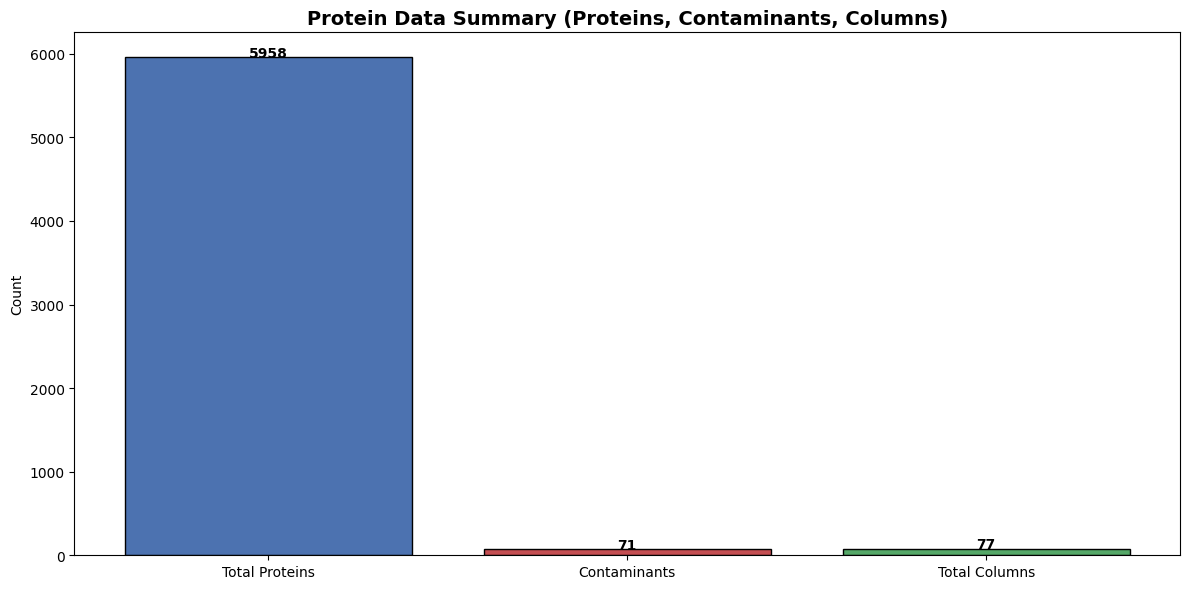

In [10]:
import matplotlib.pyplot as plt

# Include columns count
total_columns = df.shape[1]  # total features/columns

# Figure setup
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart: Total proteins, contaminants, total columns
bars = ax.bar(
    ['Total Proteins', 'Contaminants', 'Total Columns'],
    [total_proteins, num_contaminants, total_columns],
    color=['#4C72B0', '#C44E52', '#55A868'],
    edgecolor='black'
)

# Add numbers on top
for i, v in enumerate([total_proteins, num_contaminants, total_columns]):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax.set_ylabel("Count")
ax.set_title("Protein Data Summary (Proteins, Contaminants, Columns)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

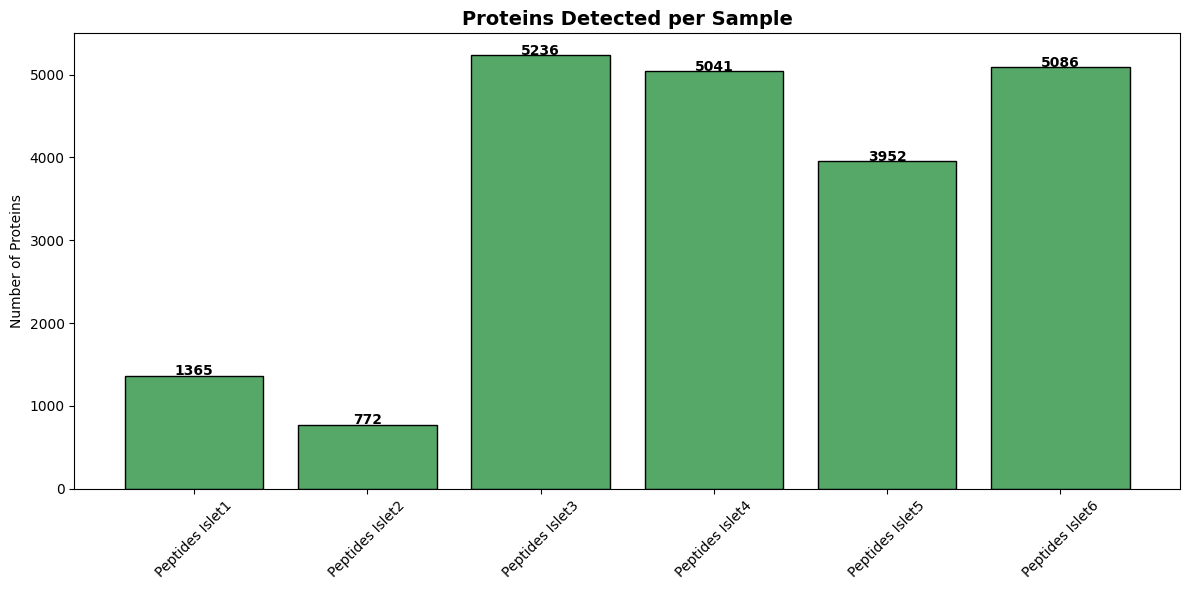

In [9]:
# Proteins detected per sample
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(proteins_per_sample.index, proteins_per_sample.values,
              color='#55A868', edgecolor='black')

# Add values on top
for i, v in enumerate(proteins_per_sample.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax.set_ylabel("Number of Proteins")
ax.set_title("Proteins Detected per Sample", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

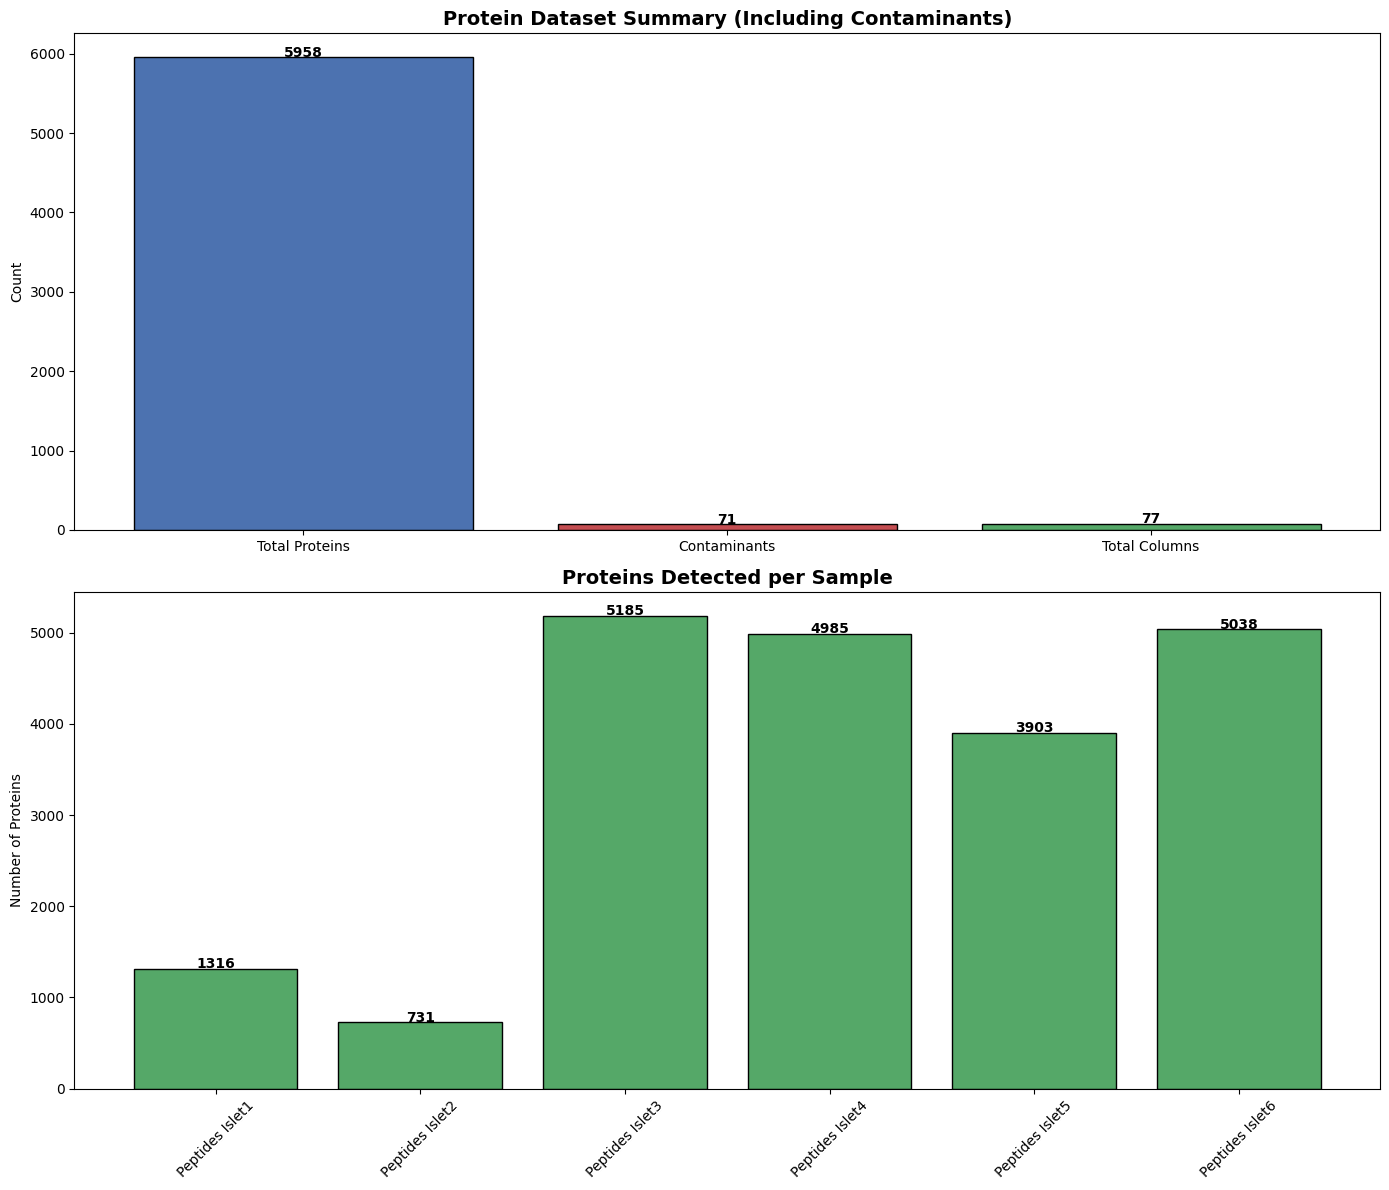

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load protein data
# -----------------------------
protein_file = "proteinGroups_search-pilot_PancreaticIslets.txt"
df = pd.read_csv(protein_file, sep="\t", low_memory=False)

# -----------------------------
# 2. Calculate counts
# -----------------------------
total_proteins = df.shape[0]               # total proteins (rows)
total_columns = df.shape[1]                # total features/columns
num_contaminants = df['Potential contaminant'].notna().sum()  # contaminants

# Remove contaminants for cleaned data (for sample per column counts)
df_clean = df[df['Potential contaminant'].isna()]

# Proteins detected per sample
peptide_columns = [c for c in df_clean.columns if c.startswith("Peptides")]
proteins_per_sample = (df_clean[peptide_columns] > 0).sum()

# -----------------------------
# 3. Create multi-part figure (2 charts)
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Part 1: Total proteins, contaminants, columns ---
axes[0].bar(
    ['Total Proteins', 'Contaminants', 'Total Columns'],
    [total_proteins, num_contaminants, total_columns],
    color=['#4C72B0', '#C44E52', '#55A868'],
    edgecolor='black'
)
for i, v in enumerate([total_proteins, num_contaminants, total_columns]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel("Count")
axes[0].set_title("Protein Dataset Summary (Including Contaminants)", fontsize=14, fontweight='bold')

# --- Part 2: Proteins detected per sample ---
axes[1].bar(proteins_per_sample.index, proteins_per_sample.values,
            color='#55A868', edgecolor='black')
for i, v in enumerate(proteins_per_sample.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_ylabel("Number of Proteins")
axes[1].set_title("Proteins Detected per Sample", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# -----------------------------
# 4. Save figure
# -----------------------------
plt.tight_layout()
plt.savefig("protein_data_summary_final.png", dpi=300)
plt.show()

In [4]:
df.columns

Index(['Protein IDs', 'Majority protein IDs', 'Peptide counts (all)',
       'Peptide counts (razor+unique)', 'Peptide counts (unique)',
       'Protein names', 'Gene names', 'Fasta headers', 'Peptides Islet1',
       'Peptides Islet2', 'Peptides Islet3', 'Peptides Islet4',
       'Peptides Islet5', 'Peptides Islet6', 'Razor + unique peptides Islet1',
       'Razor + unique peptides Islet2', 'Razor + unique peptides Islet3',
       'Razor + unique peptides Islet4', 'Razor + unique peptides Islet5',
       'Razor + unique peptides Islet6', 'Unique peptides Islet1',
       'Unique peptides Islet2', 'Unique peptides Islet3',
       'Unique peptides Islet4', 'Unique peptides Islet5',
       'Unique peptides Islet6', 'Sequence coverage [%]',
       'Unique + razor sequence coverage [%]', 'Unique sequence coverage [%]',
       'Mol. weight [kDa]', 'Sequence length', 'Sequence lengths', 'Q-value',
       'Score', 'Identification type Islet1', 'Identification type Islet2',
       'Identificati

In [5]:
df.iloc[:5, :5]

,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique)
0,Q9H1X3-3;A0A024R161;P50151,Q9H1X3-3;A0A024R161;P50151,1;1;1,1;1;1,1;1;1
1,A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,1;1,1;1,1;1
2,A0A024R216;Q9Y3E1;H3BPQ6;H3BPM9,A0A024R216;Q9Y3E1,6;6;2;2,4;4;1;2,4;4;1;2
3,A0A024R341;Q6I9Y2;F8WF22,A0A024R341;Q6I9Y2;F8WF22,3;3;2,3;3;2,3;3;2
4,A0A024R412;A0A024R3W6;Q7LBX6;X5D2Q8;O60462-4;O...,A0A024R412;A0A024R3W6;Q7LBX6;X5D2Q8;O60462-4;O...,1;1;1;1;1;1;1;1;1,1;1;1;1;1;1;1;1;1,1;1;1;1;1;1;1;1;1
